# Inicialização os Arquivos

## Buscando os datasets no Git

In [ ]:
!git clone https://github.com/Guerco/Depress-IA.git

!mv Depress-IA/experimento/datasets .

!rm -rf Depress-IA

Cloning into 'Depress-IA'...
remote: Enumerating objects: 33, done.
remote: Counting objects: 100% (33/33), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 33 (delta 7), reused 31 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (33/33), 6.70 MiB | 9.10 MiB/s, done.
Resolving deltas: 100% (7/7), done.


## Mesclando os Datasets

In [ ]:
import pandas as pd

### Combinação dos Datasets do Reddit

In [ ]:
df1 = pd.read_csv('/content/datasets/Reddit_3k.csv')
df2 = pd.read_csv('/content/datasets/Reddit_16k.csv')

df_reddit_final = pd.concat([df1, df2], ignore_index=True)

lixo = ['label', 'Label', 'Class labels', 'Class Labels', 'label data']

df_reddit_final = df_reddit_final[~df_reddit_final['label'].isin(lixo)]

df_reddit_final = df_reddit_final[['text', 'label']]

df_reddit_final.to_csv('/content/datasets/Reddit.csv', sep=',', index=False)

print("Arquivo salvo como 'Reddit.csv' com sucesso!")

print(df_reddit_final.head())

Arquivo salvo como 'Reddit.csv' com sucesso!
                                                text     label
0  He said he had not felt that way before, sugge...      mild
1  Hey there r/assistance, Not sure if this is th...   minimum
2  My mom then hit me with the newspaper and it s...   minimum
3  until i met my new boyfriend, he is amazing, h...      mild
4  October is Domestic Violence Awareness Month a...  moderate


### Criação do Dataset "Genérico"



In [ ]:
df_reddit = pd.read_csv('/content/datasets/Reddit.csv')
df_twitter = pd.read_csv('/content/datasets/Twitter.csv')

df_reddit['source'] = 'reddit'
df_twitter['source'] = 'twitter'

df_total = pd.concat([df_reddit, df_twitter], ignore_index=True)


mapeamento = {
    'mild': '1', 'moderate': '1', 'severe': '1',
    'not depression': '0', 'minimum': '0',
    '1': '1', '0': '0'
}

df_total['label'] = df_total['label'].astype(str).str.lower().str.strip().map(mapeamento)
df_total = df_total.dropna(subset=['label'])


def get_sample(df, label, source, n):
    return df[(df['label'] == label) & (df['source'] == source)].sample(n=n, random_state=69)


# Classe 0: 1812 Reddit + 1813 Twitter = 3625
c0_reddit = get_sample(df_total, '0', 'reddit', 3625)
c0_twitter = get_sample(df_total, '0', 'twitter', 3625)

# Classe 1: 1812 Reddit + 1813 Twitter = 3625
c1_reddit = get_sample(df_total, '1', 'reddit', 3625)
c1_twitter = get_sample(df_total, '1', 'twitter', 3625)



df_final = pd.concat([c0_reddit, c0_twitter, c1_reddit, c1_twitter], ignore_index=True)
df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

# df_final = df_final.drop(columns=['source'])

df_final = df_final[['text', 'label', 'source']]

df_final.to_csv('/content/datasets/Generic.csv', index=False)

print("Arquivo 'Generic.csv' salvo com 7250 linhas.")
print(df_final.groupby(['label']).size())
print(df_final.head())

Arquivo 'Generic.csv' salvo com 7250 linhas.
label
0    7250
1    7250
dtype: int64
                                                text label   source
0  RT @hjghwaytoheII: PETITION FOR MICHAEL CLIFFO...     1  twitter
1  I was thinking of maxing out two credit cards ...     0   reddit
2  In between? : Can you relate... can you help w...     1   reddit
3  It's NYE and I was rushed home by my narcissis...     1   reddit
4  Nature of depression : Basically what I see as...     0   reddit


## Instanciando Base do Facebook

label
0      83
1    1861
dtype: int64


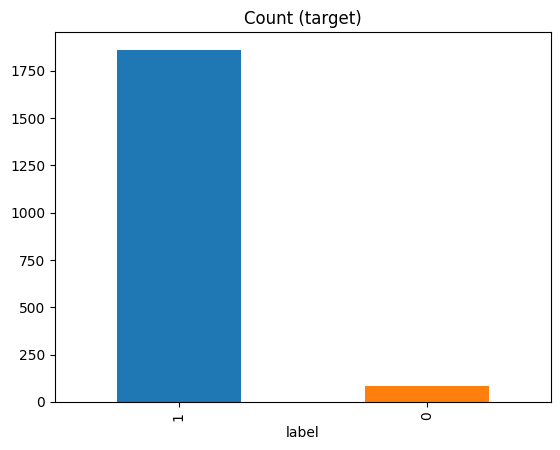

In [ ]:
base = pd.read_csv('./Facebook.csv')
base = base[['Mensagem_Traduzida', 'Predictions']]
base.columns = ['text', 'label']
print(base.groupby(['label']).size())

_label_count = base['label'].value_counts()
_label_count.plot(kind='bar', title='Count (target)',color = ['#1F77B4', '#FF7F0E']);

**Limpando Ruídos**

In [ ]:
!pip install emoji

In [ ]:
import re
import emoji

base['text'] = base['text'].apply(
    lambda x: re.sub(r'https?://\S+', '', x)
)

# Remove símbolo de hashtag mantendo a palavra
base['text'] = base['text'].apply(
    lambda x: re.sub(r'#(\w+)', r'\1', x)
)

# Remove emojis
base['text'] = base['text'].apply(
    lambda x: emoji.replace_emoji(x, replace='')
)

base['text'] = base['text'].apply(lambda x: re.sub(r'@\w+', '', x))

base['text'] = base['text'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

base['text'] = base['text'].str.lower()

base_tratamento = base.copy()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 15.1 MB/s eta 0:00:00


**Transformando as Variáveis Categóricas Binárias em Valores Numéricos**

In [ ]:
from sklearn.preprocessing import LabelEncoder

_le_label = LabelEncoder()

base_tratamento.loc[:, 'label'] = _le_label.fit_transform(base_tratamento.loc[:, 'label'].astype(str))
base_tratamento['label'] = base_tratamento['label'].astype('int64')

**Exportando como Dataset**

In [ ]:
from datasets import Dataset
import pandas as pd

df_final = base_tratamento

df_final = df_final.rename(columns={'label': 'labels'})

dataset = Dataset.from_pandas(df_final)

dataset = dataset.class_encode_column("labels")

Stringifying the column:   0%|          | 0/1944 [00:00<?, ? examples/s]

Casting to class labels:   0%|          | 0/1944 [00:00<?, ? examples/s]

**Tokenizando**

In [ ]:
!pip install -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 64.9 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "FacebookAI/roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from datasets import DatasetDict

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

dataset_tokenizado = dataset.map(tokenize_function, batched=True)

dataset_final = DatasetDict({"test": dataset_tokenizado})

Map:   0%|          | 0/1944 [00:00<?, ? examples/s]

In [ ]:
dataset_final.save_to_disk("base_tokenizada_facebook_teste")

print("Dataset salvo com sucesso como 'test'!")

Saving the dataset (0/1 shards):   0%|          | 0/1944 [00:00<?, ? examples/s]

Dataset salvo com sucesso como 'test'!


# Treinamento dos Modelos

## Treinamento Reddit

### Tratamento de Dados

**Carregando Base**

In [ ]:
import pandas as pd

base = pd.read_csv('/content/datasets/Reddit.csv')
base = base[['text', 'label']]

**Limpando Ruídos**

In [ ]:
!pip install emoji

In [ ]:
import re
import emoji

base['text'] = base['text'].apply(
    lambda x: re.sub(r'https?://\S+', '', x)
)

# Remove símbolo de hashtag mantendo a palavra
base['text'] = base['text'].apply(
    lambda x: re.sub(r'#(\w+)', r'\1', x)
)

# Remove emojis
base['text'] = base['text'].apply(
    lambda x: emoji.replace_emoji(x, replace='')
)

base['text'] = base['text'].apply(lambda x: re.sub(r'@\w+', '', x))

base['text'] = base['text'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

base['text'] = base['text'].str.lower()

base_tratamento = base.copy()

**Tratando Valores Inválidos**

label
moderate          10873
not depression     4663
minimum            2587
severe             1772
mild                290
Name: count, dtype: int64
label
1    12935
0     7250
Name: count, dtype: int64
Classe 1: 12935
Classe 0: 7250
Proportion: 0.56 : 1


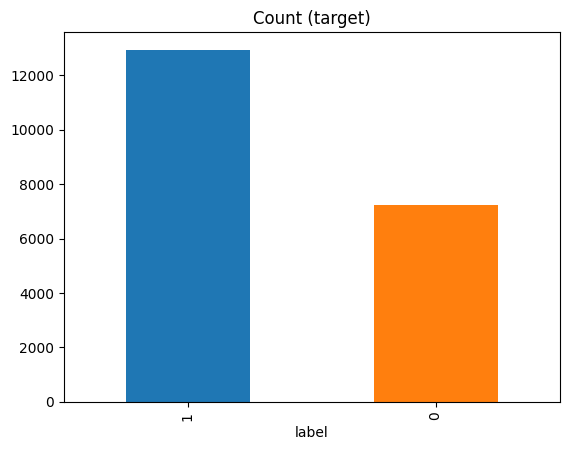

In [ ]:
print(base_tratamento['label'].value_counts())

base_tratamento.loc[base_tratamento['label'].isin(['mild', 'moderate', 'severe']), 'label'] = 1
base_tratamento.loc[base_tratamento['label'].isin(['not depression', 'minimum']), 'label'] = 0

base_tratamento = base_tratamento.dropna(subset=['label'])
print(base_tratamento['label'].value_counts())

_label_count = base_tratamento['label'].value_counts()
print('Classe 1:', _label_count[1])
print('Classe 0:', _label_count[0])
print('Proportion:', round(_label_count[0] / _label_count[1], 2), ': 1')
_label_count.plot(kind='bar', title='Count (target)',color = ['#1F77B4', '#FF7F0E']);

**Transformando as Variáveis Categóricas Binárias em Valores Numéricos**

In [ ]:
from sklearn.preprocessing import LabelEncoder

_le_label = LabelEncoder()

base_tratamento.loc[:, 'label'] = _le_label.fit_transform(base_tratamento.loc[:, 'label'].astype(str))
base_tratamento['label'] = base_tratamento['label'].astype('int64')

**Balanceamento com Undersampling**

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

_us = RandomUnderSampler(random_state=69)

print(base_tratamento['label'].value_counts())

X = base_tratamento.drop(columns=['label'])
y = base_tratamento['label']

X_resampled, y_resampled = _us.fit_resample(X, y)

base_tratamento_balanceada = X_resampled.copy()
base_tratamento_balanceada['label'] = y_resampled

print(base_tratamento_balanceada['label'].value_counts())

label
1    12935
0     7250
Name: count, dtype: int64
label
0    7250
1    7250
Name: count, dtype: int64


### Configuração do Ambiente

In [ ]:
!pip install -U transformers

**Importando o Modelo**

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "FacebookAI/roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


**Importando Dataset e Serpando entre Treino e Teste**

In [ ]:
from datasets import Dataset
import pandas as pd

df_final = base_tratamento_balanceada

df_final = df_final.rename(columns={'label': 'labels'})

dataset = Dataset.from_pandas(df_final)

dataset = dataset.class_encode_column("labels")

dataset_split = dataset.train_test_split(test_size=0.2, stratify_by_column="labels", seed=42)

Stringifying the column:   0%|          | 0/14500 [00:00<?, ? examples/s]

Casting to class labels:   0%|          | 0/14500 [00:00<?, ? examples/s]

**Tokenização**

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("FacebookAI/roberta-base")

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_datasets = dataset_split.map(tokenize_function, batched=True)

Map:   0%|          | 0/11600 [00:00<?, ? examples/s]

Map:   0%|          | 0/2900 [00:00<?, ? examples/s]

### Exportando Dataset de Teste

In [ ]:
tokenized_datasets["test"].save_to_disk("base_tokenizada_reddit_teste")

Saving the dataset (0/1 shards):   0%|          | 0/2900 [00:00<?, ? examples/s]

### Treinamento

In [ ]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.3 MB/s eta 0:00:00


In [ ]:
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
import numpy as np
import evaluate

metric_acc = evaluate.load("accuracy")
metric_f1 = evaluate.load("f1")
metric_precision = evaluate.load("precision")
metric_recall = evaluate.load("recall")


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)


    accuracy = metric_acc.compute(predictions=predictions, references=labels)
    f1 = metric_f1.compute(predictions=predictions, references=labels, average="binary")
    precision = metric_precision.compute(predictions=predictions, references=labels, average="binary")
    recall = metric_recall.compute(predictions=predictions, references=labels, average="binary")


    return {
        "accuracy": accuracy["accuracy"],
        "f1": f1["f1"],
        "precision": precision["precision"],
        "recall": recall["recall"]
    }


training_args = TrainingArguments(
    output_dir="./resultados/reddit",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,
    per_device_eval_batch_size=8,
    num_train_epochs=4,
    weight_decay=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_dir='./logs',
    warmup_ratio=0.1,
    logging_steps=50,
    label_smoothing_factor=0.1,
)

print(tokenized_datasets["train"].column_names)

tokenized_datasets = tokenized_datasets.map(
    lambda x: {"labels": int(x["labels"])},
    batched=False
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)


trainer.train()


model.save_pretrained("./modelos/reddit")
tokenizer.save_pretrained("./modelos/reddit/tokenizador")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


['text', 'labels', '__index_level_0__', 'input_ids', 'attention_mask']


Map:   0%|          | 0/11600 [00:00<?, ? examples/s]

Map:   0%|          | 0/2900 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.039510,0.517297,0.791379,0.796912,0.776324,0.818621
2,0.925450,0.500610,0.798966,0.814154,0.756965,0.880690
3,0.862395,0.485997,0.805862,0.811643,0.788174,0.836552
4,0.765370,0.506128,0.798966,0.804821,0.782043,0.828966


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./modelos/reddit/tokenizador/tokenizer_config.json',
 './modelos/reddit/tokenizador/tokenizer.json')

## Treinamento Twitter

### Tratamento de Dados

**Carregando a Base**

In [ ]:
import pandas as pd

In [ ]:
base = pd.read_csv('/content/datasets/Twitter.csv')
base = base[['text', 'label']]

**Limpando Ruídos**

In [ ]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 12.0 MB/s eta 0:00:00


In [ ]:
import re
import emoji

base['text'] = base['text'].astype(str).apply(
    lambda x: re.sub(r'RT\s+@\w+:\s*', '', x)
)

base['text'] = base['text'].apply(
    lambda x: re.sub(r'https?://\S+', '', x)
)

# Remove símbolo de hashtag mantendo a palavra
base['text'] = base['text'].apply(
    lambda x: re.sub(r'#(\w+)', r'\1', x)
)

# Remove emojis
base['text'] = base['text'].apply(
    lambda x: emoji.replace_emoji(x, replace='')
)

base['text'] = base['text'].apply(lambda x: re.sub(r'@\w+', '', x))

base['text'] = base['text'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

base['text'] = base['text'].str.lower()

base_tratamento = base.copy()

**Transformando as Variáveis Categóricas Binárias em Valores Numéricos**

In [ ]:
from sklearn.preprocessing import LabelEncoder

_le_label = LabelEncoder()

base_tratamento.loc[:, 'label'] = _le_label.fit_transform(base_tratamento.loc[:, 'label'].astype(str))
base_tratamento['label'] = base_tratamento['label'].astype('int64')

**Balanceamento com Undersampling**

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

amostragem_alvo = {0: 7250, 1: 7250}

_us = RandomUnderSampler(sampling_strategy=amostragem_alvo, random_state=69)

print(base_tratamento['label'].value_counts())

X = base_tratamento.drop(columns=['label'])
y = base_tratamento['label']

X_resampled, y_resampled = _us.fit_resample(X, y)

base_tratamento_balanceada = X_resampled.copy()
base_tratamento_balanceada['label'] = y_resampled

print(base_tratamento_balanceada['label'].value_counts())

label
1    10000
0    10000
Name: count, dtype: int64
label
0    7250
1    7250
Name: count, dtype: int64


### Configuração do Ambiente

In [ ]:
!pip install -U transformers

**Importando o Modelo**

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "FacebookAI/roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


**Importando Dataset**

In [ ]:
from datasets import Dataset
import pandas as pd

df_final = base_tratamento_balanceada

df_final = df_final.rename(columns={'label': 'labels'})

dataset = Dataset.from_pandas(df_final)

dataset = dataset.class_encode_column("labels")

dataset_split = dataset.train_test_split(test_size=0.2, stratify_by_column="labels", seed=42)

Stringifying the column:   0%|          | 0/14500 [00:00<?, ? examples/s]

Casting to class labels:   0%|          | 0/14500 [00:00<?, ? examples/s]

**Tokenização**

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("FacebookAI/roberta-base")

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_datasets = dataset_split.map(tokenize_function, batched=True)

Map:   0%|          | 0/11600 [00:00<?, ? examples/s]

Map:   0%|          | 0/2900 [00:00<?, ? examples/s]

### Exportando Dataset de Teste

In [ ]:
tokenized_datasets["test"].save_to_disk("base_tokenizada_twitter_teste")

Saving the dataset (0/1 shards):   0%|          | 0/2900 [00:00<?, ? examples/s]

### Treinamento

In [ ]:
!pip install evaluate

In [ ]:
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
import numpy as np
import evaluate


metric_acc = evaluate.load("accuracy")
metric_f1 = evaluate.load("f1")
metric_precision = evaluate.load("precision")
metric_recall = evaluate.load("recall")


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)


    accuracy = metric_acc.compute(predictions=predictions, references=labels)
    f1 = metric_f1.compute(predictions=predictions, references=labels, average="binary")
    precision = metric_precision.compute(predictions=predictions, references=labels, average="binary")
    recall = metric_recall.compute(predictions=predictions, references=labels, average="binary")


    return {
        "accuracy": accuracy["accuracy"],
        "f1": f1["f1"],
        "precision": precision["precision"],
        "recall": recall["recall"]
    }


training_args = TrainingArguments(
    output_dir="./resultados/twitter",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,
    per_device_eval_batch_size=8,
    num_train_epochs=4,
    weight_decay=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_dir='./logs',
    warmup_ratio=0.1,
    logging_steps=50,
    label_smoothing_factor=0.1,
)

print(tokenized_datasets["train"].column_names)

tokenized_datasets = tokenized_datasets.map(
    lambda x: {"labels": int(x["labels"])},
    batched=False
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)


trainer.train()


model.save_pretrained("./modelos/twitter")
tokenizer.save_pretrained("./modelos/twitter/tokenizador")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


['text', 'labels', '__index_level_0__', 'input_ids', 'attention_mask']


Map:   0%|          | 0/11600 [00:00<?, ? examples/s]

Map:   0%|          | 0/2900 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.056262,0.501816,0.770690,0.780745,0.747947,0.816552
2,0.903469,0.477533,0.804483,0.811063,0.784655,0.839310
3,0.776291,0.481310,0.811034,0.821615,0.778052,0.870345
4,0.748000,0.488334,0.810690,0.814965,0.796968,0.833793


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./modelos/twitter/tokenizador/tokenizer_config.json',
 './modelos/twitter/tokenizador/tokenizer.json')

## Treinamento Generalista

### Tratamento de Dados

**Carregando a Base**

In [ ]:
import pandas as pd

In [ ]:
base = pd.read_csv('/content/datasets/Generic.csv')
base = base[['text', 'label', 'source']]

**Limpando Ruídos**

In [ ]:
!pip install emoji

In [ ]:
import re
import emoji

base['text'] = base['text'].astype(str).apply(
    lambda x: re.sub(r'RT\s+@\w+:\s*', '', x)
)

base['text'] = base['text'].apply(
    lambda x: re.sub(r'https?://\S+', '', x)
)

# Remove símbolo de hashtag mantendo a palavra
base['text'] = base['text'].apply(
    lambda x: re.sub(r'#(\w+)', r'\1', x)
)

# Remove emojis
base['text'] = base['text'].apply(
    lambda x: emoji.replace_emoji(x, replace='')
)

base['text'] = base['text'].apply(lambda x: re.sub(r'@\w+', '', x))

base['text'] = base['text'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

base['text'] = base['text'].str.lower()

base_tratamento = base.copy()

**Tratando Valores Inválidos**

label
1    7250
0    7250
Name: count, dtype: int64
Classe 1: 7250
Classe 0: 7250
Proportion: 1.0 : 1


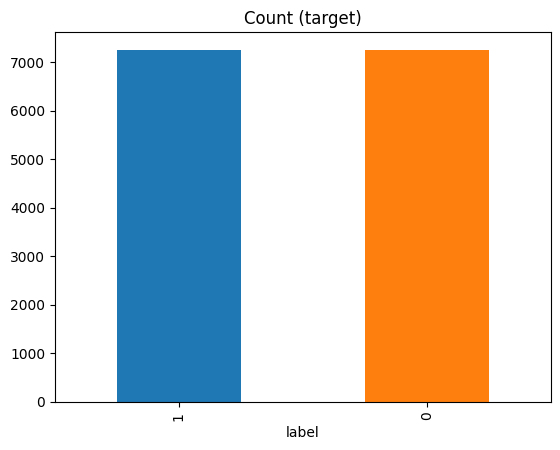

In [ ]:
base_tratamento['label'] = base_tratamento['label'].astype(str)

mapeamento = {
    'mild': '1',
    'moderate': '1',
    'severe': '1',
    'not depression': '0',
    'minimum': '0',
    '1': '1',
    '0': '0'
}

base_tratamento['label'] = base_tratamento['label'].replace(mapeamento)

base_tratamento['label'] = base_tratamento['label'].astype(int)

print(base_tratamento['label'].value_counts())

_label_count = base_tratamento['label'].value_counts()
print('Classe 1:', _label_count[1])
print('Classe 0:', _label_count[0])
print('Proportion:', round(_label_count[0] / _label_count[1], 2), ': 1')
_label_count.plot(kind='bar', title='Count (target)',color = ['#1F77B4', '#FF7F0E']);

**Transformando as Variáveis Categóricas Binárias em Valores Numéricos**

In [ ]:
from sklearn.preprocessing import LabelEncoder

_le_label = LabelEncoder()

base_tratamento.loc[:, 'label'] = _le_label.fit_transform(base_tratamento.loc[:, 'label'].astype(str))
base_tratamento['label'] = base_tratamento['label'].astype('int64')

**Balanceamento com Undersampling**

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

amostragem_alvo = {0: 7250, 1: 7250}

_us = RandomUnderSampler(sampling_strategy=amostragem_alvo, random_state=69)

print(base_tratamento['label'].value_counts())

X = base_tratamento.drop(columns=['label'])
y = base_tratamento['label']

X_resampled, y_resampled = _us.fit_resample(X, y)

base_tratamento_balanceada = X_resampled.copy()
base_tratamento_balanceada['label'] = y_resampled

print(base_tratamento_balanceada['label'].value_counts())

label
1    7250
0    7250
Name: count, dtype: int64
label
0    7250
1    7250
Name: count, dtype: int64


### Configuração do Ambiente

In [ ]:
!pip install -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 116.3 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


### Importando o Modelo

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "FacebookAI/roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Importando Dataset e Separando entre Treino e Teste

In [ ]:
from datasets import Dataset
import pandas as pd

df_final = base_tratamento_balanceada

print(df_final.columns)

df_final['stratify_col'] = df_final['label'].astype(str) + "_" + df_final['source']

df_final = df_final.rename(columns={'label': 'labels'})

dataset = Dataset.from_pandas(df_final)

dataset = dataset.class_encode_column("stratify_col")

dataset_split = dataset.train_test_split(
    test_size=0.2,
    stratify_by_column="stratify_col",
    seed=42
)

dataset_split = dataset_split.remove_columns(['stratify_col'])

Index(['text', 'source', 'label'], dtype='object')


Casting to class labels:   0%|          | 0/14500 [00:00<?, ? examples/s]

### Tokenização

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("FacebookAI/roberta-base")

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_datasets = dataset_split.map(tokenize_function, batched=True)

Map:   0%|          | 0/11600 [00:00<?, ? examples/s]

Map:   0%|          | 0/2900 [00:00<?, ? examples/s]

### Exportando Dataset de Teste

In [ ]:
tokenized_datasets["test"].save_to_disk("base_tokenizada_generic_teste")

Saving the dataset (0/1 shards):   0%|          | 0/2900 [00:00<?, ? examples/s]

### Treinamento

In [ ]:
!pip install evaluate

In [ ]:
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
import numpy as np
import evaluate


metric_acc = evaluate.load("accuracy")
metric_f1 = evaluate.load("f1")
metric_precision = evaluate.load("precision")
metric_recall = evaluate.load("recall")


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)


    accuracy = metric_acc.compute(predictions=predictions, references=labels)
    f1 = metric_f1.compute(predictions=predictions, references=labels, average="binary")
    precision = metric_precision.compute(predictions=predictions, references=labels, average="binary")
    recall = metric_recall.compute(predictions=predictions, references=labels, average="binary")


    return {
        "accuracy": accuracy["accuracy"],
        "f1": f1["f1"],
        "precision": precision["precision"],
        "recall": recall["recall"]
    }


training_args = TrainingArguments(
    output_dir="./resultados/generic",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,
    per_device_eval_batch_size=8,
    num_train_epochs=4,
    weight_decay=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_dir='./logs',
    warmup_ratio=0.1,
    logging_steps=50,
    label_smoothing_factor=0.1,
)

print(tokenized_datasets["train"].column_names)

tokenized_datasets = tokenized_datasets.map(
    lambda x: {"labels": int(x["labels"])},
    batched=False
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)


trainer.train()


model.save_pretrained("./modelos/generic")
tokenizer.save_pretrained("./modelos/generic/tokenizador")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


['text', 'source', 'labels', '__index_level_0__', 'input_ids', 'attention_mask']


Map:   0%|          | 0/11600 [00:00<?, ? examples/s]

Map:   0%|          | 0/2900 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.956077,0.431462,0.847241,0.856402,0.807951,0.911034
2,0.814432,0.416528,0.856207,0.858115,0.846877,0.869655
3,0.711836,0.436274,0.854483,0.856658,0.844043,0.869655
4,0.671367,0.442764,0.861034,0.863158,0.850167,0.876552


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./modelos/generic/tokenizador/tokenizer_config.json',
 './modelos/generic/tokenizador/tokenizer.json')

# Cenários de Teste

## Twitter x Base Twitter

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import load_from_disk
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import evaluate

# Carregar o modelo já treinado no Twitter
model = AutoModelForSequenceClassification.from_pretrained("./modelos/twitter")
tokenizer = AutoTokenizer.from_pretrained("./modelos/twitter/tokenizador")

# Carregar a base tokenizada do Twitter (já pronta)
reddit_test = load_from_disk("./base_tokenizada_twitter_teste")


metric_acc = evaluate.load("accuracy")
metric_f1 = evaluate.load("f1")
metric_precision = evaluate.load("precision")
metric_recall = evaluate.load("recall")


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = metric_acc.compute(predictions=predictions, references=labels)
    f1 = metric_f1.compute(predictions=predictions, references=labels, average="binary")
    precision = metric_precision.compute(predictions=predictions, references=labels, average="binary")
    recall = metric_recall.compute(predictions=predictions, references=labels, average="binary")

    return {
        "accuracy": acc["accuracy"],
        "f1": f1["f1"],
        "precision": precision["precision"],
        "recall": recall["recall"]
    }


trainer = Trainer(
    model=model,
    compute_metrics=compute_metrics,
)

results = trainer.evaluate(eval_dataset=reddit_test)
print(results)


predictions_output = trainer.predict(reddit_test)

preds  = np.argmax(predictions_output.predictions, axis=-1)
labels = predictions_output.label_ids

print("\n--- Relatório de Classificação ---")
print(classification_report(labels, preds, target_names=["Sem depressão", "Com Depressão"]))

print("\n--- Matriz de Confusão ---")
print(confusion_matrix(labels, preds))

print("\n")

# Exibir alguns exemplos
for i in range(10):
    print(f"Real: {labels[i]} | Predito: {preds[i]}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Training Loss,Validation Loss,Step,Accuracy,F1,Precision,Recall
No log,0.399197,0,0.811034,0.821615,0.778052,0.870345


{'eval_loss': 0.3991970419883728, 'eval_accuracy': 0.8110344827586207, 'eval_f1': 0.8216145833333334, 'eval_precision': 0.7780517879161529, 'eval_recall': 0.8703448275862069}



--- Relatório de Classificação ---
               precision    recall  f1-score   support

Sem depressão       0.85      0.75      0.80      1450
Com Depressão       0.78      0.87      0.82      1450

     accuracy                           0.81      2900
    macro avg       0.82      0.81      0.81      2900
 weighted avg       0.82      0.81      0.81      2900


--- Matriz de Confusão ---
[[1090  360]
 [ 188 1262]]


Real: 0 | Predito: 0
Real: 0 | Predito: 0
Real: 0 | Predito: 0
Real: 0 | Predito: 1
Real: 0 | Predito: 0
Real: 0 | Predito: 0
Real: 1 | Predito: 1
Real: 1 | Predito: 1
Real: 1 | Predito: 0
Real: 0 | Predito: 1


## Reddit x Base Reddit

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import classification_report, confusion_matrix
from datasets import load_from_disk
import numpy as np
import evaluate

# Carregar o modelo já treinado no Reddit
model = AutoModelForSequenceClassification.from_pretrained("./modelos/reddit")
tokenizer = AutoTokenizer.from_pretrained("./modelos/reddit/tokenizador")

# Carregar a base tokenizada do Reddit
reddit_test = load_from_disk("./base_tokenizada_reddit_teste")


metric_acc = evaluate.load("accuracy")
metric_f1 = evaluate.load("f1")
metric_precision = evaluate.load("precision")
metric_recall = evaluate.load("recall")


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = metric_acc.compute(predictions=predictions, references=labels)
    f1 = metric_f1.compute(predictions=predictions, references=labels, average="binary")
    precision = metric_precision.compute(predictions=predictions, references=labels, average="binary")
    recall = metric_recall.compute(predictions=predictions, references=labels, average="binary")

    return {
        "accuracy": acc["accuracy"],
        "f1": f1["f1"],
        "precision": precision["precision"],
        "recall": recall["recall"]
    }


trainer = Trainer(
    model=model,
    compute_metrics=compute_metrics,
)

results = trainer.evaluate(eval_dataset=reddit_test)
print(results)


predictions_output = trainer.predict(reddit_test)

preds  = np.argmax(predictions_output.predictions, axis=-1)
labels = predictions_output.label_ids

print("\n--- Relatório de Classificação ---")
print(classification_report(labels, preds, target_names=["Sem depressão", "Com Depressão"]))

print("\n--- Matriz de Confusão ---")
print(confusion_matrix(labels, preds))

print("\n")

# Exibir alguns exemplos
for i in range(10):
    print(f"Real: {labels[i]} | Predito: {preds[i]}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Training Loss,Validation Loss,Step,Accuracy,F1,Precision,Recall
No log,0.435514,0,0.798966,0.814154,0.756965,0.880690


{'eval_loss': 0.43551358580589294, 'eval_accuracy': 0.7989655172413793, 'eval_f1': 0.8141536499840613, 'eval_precision': 0.7569650266745702, 'eval_recall': 0.8806896551724138}



--- Relatório de Classificação ---
               precision    recall  f1-score   support

Sem depressão       0.86      0.72      0.78      1450
Com Depressão       0.76      0.88      0.81      1450

     accuracy                           0.80      2900
    macro avg       0.81      0.80      0.80      2900
 weighted avg       0.81      0.80      0.80      2900


--- Matriz de Confusão ---
[[1040  410]
 [ 173 1277]]


Real: 0 | Predito: 0
Real: 0 | Predito: 1
Real: 0 | Predito: 0
Real: 0 | Predito: 0
Real: 0 | Predito: 0
Real: 0 | Predito: 0
Real: 1 | Predito: 1
Real: 1 | Predito: 1
Real: 1 | Predito: 1
Real: 0 | Predito: 0


## Reddit x Base Twitter

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import load_from_disk
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import evaluate

# Carregar o modelo já treinado no Reddit
model = AutoModelForSequenceClassification.from_pretrained("./modelos/reddit")
tokenizer = AutoTokenizer.from_pretrained("./modelos/reddit/tokenizador")

# Carregar a base tokenizada do Twitter (já pronta)
reddit_test = load_from_disk("./base_tokenizada_twitter_teste")


metric_acc = evaluate.load("accuracy")
metric_f1 = evaluate.load("f1")
metric_precision = evaluate.load("precision")
metric_recall = evaluate.load("recall")


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = metric_acc.compute(predictions=predictions, references=labels)
    f1 = metric_f1.compute(predictions=predictions, references=labels, average="binary")
    precision = metric_precision.compute(predictions=predictions, references=labels, average="binary")
    recall = metric_recall.compute(predictions=predictions, references=labels, average="binary")

    return {
        "accuracy": acc["accuracy"],
        "f1": f1["f1"],
        "precision": precision["precision"],
        "recall": recall["recall"]
    }


trainer = Trainer(
    model=model,
    compute_metrics=compute_metrics,
)

results = trainer.evaluate(eval_dataset=reddit_test)
print(results)


predictions_output = trainer.predict(reddit_test)

preds  = np.argmax(predictions_output.predictions, axis=-1)
labels = predictions_output.label_ids

print("\n--- Relatório de Classificação ---")
print(classification_report(labels, preds, target_names=["Sem depressão", "Com Depressão"]))

print("\n--- Matriz de Confusão ---")
print(confusion_matrix(labels, preds))

print("\n")

# Exibir alguns exemplos
for i in range(10):
    print(f"Real: {labels[i]} | Predito: {preds[i]}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Training Loss,Validation Loss,Step,Accuracy,F1,Precision,Recall
No log,1.129396,0,0.516207,0.102367,0.707965,0.055172


{'eval_loss': 1.1293964385986328, 'eval_accuracy': 0.5162068965517241, 'eval_f1': 0.10236724248240563, 'eval_precision': 0.7079646017699115, 'eval_recall': 0.05517241379310345}



--- Relatório de Classificação ---
               precision    recall  f1-score   support

Sem depressão       0.51      0.98      0.67      1450
Com Depressão       0.71      0.06      0.10      1450

     accuracy                           0.52      2900
    macro avg       0.61      0.52      0.39      2900
 weighted avg       0.61      0.52      0.39      2900


--- Matriz de Confusão ---
[[1417   33]
 [1370   80]]


Real: 0 | Predito: 0
Real: 0 | Predito: 0
Real: 0 | Predito: 0
Real: 0 | Predito: 0
Real: 0 | Predito: 0
Real: 0 | Predito: 0
Real: 1 | Predito: 0
Real: 1 | Predito: 0
Real: 1 | Predito: 0
Real: 0 | Predito: 0


## Twitter x Base Reddit

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import load_from_disk
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import evaluate

# Carregar o modelo já treinado no Twitter
model = AutoModelForSequenceClassification.from_pretrained("./modelos/twitter")
tokenizer = AutoTokenizer.from_pretrained("./modelos/twitter/tokenizador")

# Carregar a base tokenizada do Reddit
reddit_test = load_from_disk("./base_tokenizada_reddit_teste")


metric_acc = evaluate.load("accuracy")
metric_f1 = evaluate.load("f1")
metric_precision = evaluate.load("precision")
metric_recall = evaluate.load("recall")


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = metric_acc.compute(predictions=predictions, references=labels)
    f1 = metric_f1.compute(predictions=predictions, references=labels, average="binary")
    precision = metric_precision.compute(predictions=predictions, references=labels, average="binary")
    recall = metric_recall.compute(predictions=predictions, references=labels, average="binary")

    return {
        "accuracy": acc["accuracy"],
        "f1": f1["f1"],
        "precision": precision["precision"],
        "recall": recall["recall"]
    }


trainer = Trainer(
    model=model,
    compute_metrics=compute_metrics,
)

results = trainer.evaluate(eval_dataset=reddit_test)
print(results)


predictions_output = trainer.predict(reddit_test)

preds  = np.argmax(predictions_output.predictions, axis=-1)
labels = predictions_output.label_ids

print("\n--- Relatório de Classificação ---")
print(classification_report(labels, preds, target_names=["Sem depressão", "Com Depressão"]))

print("\n--- Matriz de Confusão ---")
print(confusion_matrix(labels, preds))

print("\n")

# Exibir alguns exemplos
for i in range(10):
    print(f"Real: {labels[i]} | Predito: {preds[i]}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Training Loss,Validation Loss,Step,Accuracy,F1,Precision,Recall
No log,0.915134,0,0.567586,0.691437,0.537490,0.968966


{'eval_loss': 0.9151337742805481, 'eval_accuracy': 0.5675862068965517, 'eval_f1': 0.6914370078740157, 'eval_precision': 0.5374904361132364, 'eval_recall': 0.9689655172413794}



--- Relatório de Classificação ---
               precision    recall  f1-score   support

Sem depressão       0.84      0.17      0.28      1450
Com Depressão       0.54      0.97      0.69      1450

     accuracy                           0.57      2900
    macro avg       0.69      0.57      0.48      2900
 weighted avg       0.69      0.57      0.48      2900


--- Matriz de Confusão ---
[[ 241 1209]
 [  45 1405]]


Real: 0 | Predito: 0
Real: 0 | Predito: 1
Real: 0 | Predito: 0
Real: 0 | Predito: 1
Real: 0 | Predito: 1
Real: 0 | Predito: 0
Real: 1 | Predito: 1
Real: 1 | Predito: 1
Real: 1 | Predito: 1
Real: 0 | Predito: 1


## Twitter x Base Genérica

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import load_from_disk
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import evaluate

# Carregar o modelo já treinado no Twitter
model = AutoModelForSequenceClassification.from_pretrained("./modelos/twitter")
tokenizer = AutoTokenizer.from_pretrained("./modelos/twitter/tokenizador")

# Carregar a base tokenizada do Reddit (já pronta)
reddit_test = load_from_disk("./base_tokenizada_generic_teste")


metric_acc = evaluate.load("accuracy")
metric_f1 = evaluate.load("f1")
metric_precision = evaluate.load("precision")
metric_recall = evaluate.load("recall")


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = metric_acc.compute(predictions=predictions, references=labels)
    f1 = metric_f1.compute(predictions=predictions, references=labels, average="binary")
    precision = metric_precision.compute(predictions=predictions, references=labels, average="binary")
    recall = metric_recall.compute(predictions=predictions, references=labels, average="binary")

    return {
        "accuracy": acc["accuracy"],
        "f1": f1["f1"],
        "precision": precision["precision"],
        "recall": recall["recall"]
    }


trainer = Trainer(
    model=model,
    compute_metrics=compute_metrics,
)

results = trainer.evaluate(eval_dataset=reddit_test)
print(results)


predictions_output = trainer.predict(reddit_test)

preds  = np.argmax(predictions_output.predictions, axis=-1)
labels = predictions_output.label_ids

print("\n--- Relatório de Classificação ---")
print(classification_report(labels, preds, target_names=["Sem depressão", "Com Depressão"]))

print("\n--- Matriz de Confusão ---")
print(confusion_matrix(labels, preds))

print("\n")

# Exibir alguns exemplos
for i in range(10):
    print(f"Real: {labels[i]} | Predito: {preds[i]}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Training Loss,Validation Loss,Step,Accuracy,F1,Precision,Recall
No log,0.602096,0,0.722069,0.771930,0.654511,0.940690


{'eval_loss': 0.6020958423614502, 'eval_accuracy': 0.7220689655172414, 'eval_f1': 0.7719298245614035, 'eval_precision': 0.654510556621881, 'eval_recall': 0.9406896551724138}



--- Relatório de Classificação ---
               precision    recall  f1-score   support

Sem depressão       0.89      0.50      0.64      1450
Com Depressão       0.65      0.94      0.77      1450

     accuracy                           0.72      2900
    macro avg       0.77      0.72      0.71      2900
 weighted avg       0.77      0.72      0.71      2900


--- Matriz de Confusão ---
[[ 730  720]
 [  86 1364]]


Real: 1 | Predito: 1
Real: 1 | Predito: 1
Real: 1 | Predito: 0
Real: 0 | Predito: 1
Real: 0 | Predito: 0
Real: 0 | Predito: 0
Real: 1 | Predito: 1
Real: 1 | Predito: 1
Real: 0 | Predito: 1
Real: 1 | Predito: 1


## Reddit x Base Genérica

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import load_from_disk
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import evaluate

# Carregar o modelo já treinado no Twitter
model = AutoModelForSequenceClassification.from_pretrained("./modelos/reddit")
tokenizer = AutoTokenizer.from_pretrained("./modelos/reddit/tokenizador")

# Carregar a base tokenizada do Reddit
reddit_test = load_from_disk("./base_tokenizada_generic_teste")


metric_acc = evaluate.load("accuracy")
metric_f1 = evaluate.load("f1")
metric_precision = evaluate.load("precision")
metric_recall = evaluate.load("recall")


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = metric_acc.compute(predictions=predictions, references=labels)
    f1 = metric_f1.compute(predictions=predictions, references=labels, average="binary")
    precision = metric_precision.compute(predictions=predictions, references=labels, average="binary")
    recall = metric_recall.compute(predictions=predictions, references=labels, average="binary")

    return {
        "accuracy": acc["accuracy"],
        "f1": f1["f1"],
        "precision": precision["precision"],
        "recall": recall["recall"]
    }


trainer = Trainer(
    model=model,
    compute_metrics=compute_metrics,
)

results = trainer.evaluate(eval_dataset=reddit_test)
print(results)


predictions_output = trainer.predict(reddit_test)

preds  = np.argmax(predictions_output.predictions, axis=-1)
labels = predictions_output.label_ids

print("\n--- Relatório de Classificação ---")
print(classification_report(labels, preds, target_names=["Sem depressão", "Com Depressão"]))

print("\n--- Matriz de Confusão ---")
print(confusion_matrix(labels, preds))

print("\n")

# Exibir alguns exemplos
for i in range(10):
    print(f"Real: {labels[i]} | Predito: {preds[i]}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Training Loss,Validation Loss,Step,Accuracy,F1,Precision,Recall
No log,0.739666,0,0.680000,0.601032,0.797945,0.482069


{'eval_loss': 0.7396663427352905, 'eval_accuracy': 0.68, 'eval_f1': 0.6010318142734308, 'eval_precision': 0.797945205479452, 'eval_recall': 0.4820689655172414}



--- Relatório de Classificação ---
               precision    recall  f1-score   support

Sem depressão       0.63      0.88      0.73      1450
Com Depressão       0.80      0.48      0.60      1450

     accuracy                           0.68      2900
    macro avg       0.71      0.68      0.67      2900
 weighted avg       0.71      0.68      0.67      2900


--- Matriz de Confusão ---
[[1273  177]
 [ 751  699]]


Real: 1 | Predito: 1
Real: 1 | Predito: 1
Real: 1 | Predito: 1
Real: 0 | Predito: 0
Real: 0 | Predito: 0
Real: 0 | Predito: 0
Real: 1 | Predito: 0
Real: 1 | Predito: 0
Real: 0 | Predito: 0
Real: 1 | Predito: 0


## Modelo Genérico x Base Twitter

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import load_from_disk
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import evaluate

# Carregar o modelo já treinado no Twitter
model = AutoModelForSequenceClassification.from_pretrained("./modelos/generic")
tokenizer = AutoTokenizer.from_pretrained("./modelos/generic/tokenizador")

# Carregar a base tokenizada do Reddit (já pronta)
reddit_test = load_from_disk("./base_tokenizada_twitter_teste")


metric_acc = evaluate.load("accuracy")
metric_f1 = evaluate.load("f1")
metric_precision = evaluate.load("precision")
metric_recall = evaluate.load("recall")


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = metric_acc.compute(predictions=predictions, references=labels)
    f1 = metric_f1.compute(predictions=predictions, references=labels, average="binary")
    precision = metric_precision.compute(predictions=predictions, references=labels, average="binary")
    recall = metric_recall.compute(predictions=predictions, references=labels, average="binary")

    return {
        "accuracy": acc["accuracy"],
        "f1": f1["f1"],
        "precision": precision["precision"],
        "recall": recall["recall"]
    }


trainer = Trainer(
    model=model,
    compute_metrics=compute_metrics,
)

results = trainer.evaluate(eval_dataset=reddit_test)
print(results)


predictions_output = trainer.predict(reddit_test)

preds  = np.argmax(predictions_output.predictions, axis=-1)
labels = predictions_output.label_ids

print("\n--- Relatório de Classificação ---")
print(classification_report(labels, preds, target_names=["Sem depressão", "Com Depressão"]))

print("\n--- Matriz de Confusão ---")
print(confusion_matrix(labels, preds))

print("\n")

# Exibir alguns exemplos
for i in range(10):
    print(f"Real: {labels[i]} | Predito: {preds[i]}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Training Loss,Validation Loss,Step,Accuracy,F1,Precision,Recall
No log,0.324747,0,0.866207,0.868742,0.852590,0.885517


{'eval_loss': 0.3247471749782562, 'eval_accuracy': 0.8662068965517241, 'eval_f1': 0.8687415426251691, 'eval_precision': 0.852589641434263, 'eval_recall': 0.8855172413793103}



--- Relatório de Classificação ---
               precision    recall  f1-score   support

Sem depressão       0.88      0.85      0.86      1450
Com Depressão       0.85      0.89      0.87      1450

     accuracy                           0.87      2900
    macro avg       0.87      0.87      0.87      2900
 weighted avg       0.87      0.87      0.87      2900


--- Matriz de Confusão ---
[[1228  222]
 [ 166 1284]]


Real: 0 | Predito: 0
Real: 0 | Predito: 0
Real: 0 | Predito: 1
Real: 0 | Predito: 0
Real: 0 | Predito: 0
Real: 0 | Predito: 0
Real: 1 | Predito: 1
Real: 1 | Predito: 1
Real: 1 | Predito: 0
Real: 0 | Predito: 1


## Modelo Genérico x Base Reddit

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import load_from_disk
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import evaluate

# Carregar o modelo já treinado no Twitter
model = AutoModelForSequenceClassification.from_pretrained("./modelos/generic")
tokenizer = AutoTokenizer.from_pretrained("./modelos/generic/tokenizador")

# Carregar a base tokenizada do Reddit (já pronta)
reddit_test = load_from_disk("./base_tokenizada_reddit_teste")

metric_acc = evaluate.load("accuracy")
metric_f1 = evaluate.load("f1")
metric_precision = evaluate.load("precision")
metric_recall = evaluate.load("recall")


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = metric_acc.compute(predictions=predictions, references=labels)
    f1 = metric_f1.compute(predictions=predictions, references=labels, average="binary")
    precision = metric_precision.compute(predictions=predictions, references=labels, average="binary")
    recall = metric_recall.compute(predictions=predictions, references=labels, average="binary")

    return {
        "accuracy": acc["accuracy"],
        "f1": f1["f1"],
        "precision": precision["precision"],
        "recall": recall["recall"]
    }


trainer = Trainer(
    model=model,
    compute_metrics=compute_metrics,
)

results = trainer.evaluate(eval_dataset=reddit_test)
print(results)


predictions_output = trainer.predict(reddit_test)

preds  = np.argmax(predictions_output.predictions, axis=-1)
labels = predictions_output.label_ids

print("\n--- Relatório de Classificação ---")
print(classification_report(labels, preds, target_names=["Sem depressão", "Com Depressão"]))

print("\n--- Matriz de Confusão ---")
print(confusion_matrix(labels, preds))

print("\n")

# Exibir alguns exemplos
for i in range(10):
    print(f"Real: {labels[i]} | Predito: {preds[i]}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Training Loss,Validation Loss,Step,Accuracy,F1,Precision,Recall
No log,0.368226,0,0.856552,0.859079,0.844208,0.874483


{'eval_loss': 0.3682262897491455, 'eval_accuracy': 0.856551724137931, 'eval_f1': 0.8590785907859079, 'eval_precision': 0.844207723035952, 'eval_recall': 0.8744827586206897}



--- Relatório de Classificação ---
               precision    recall  f1-score   support

Sem depressão       0.87      0.84      0.85      1450
Com Depressão       0.84      0.87      0.86      1450

     accuracy                           0.86      2900
    macro avg       0.86      0.86      0.86      2900
 weighted avg       0.86      0.86      0.86      2900


--- Matriz de Confusão ---
[[1216  234]
 [ 182 1268]]


Real: 0 | Predito: 0
Real: 0 | Predito: 0
Real: 0 | Predito: 0
Real: 0 | Predito: 0
Real: 0 | Predito: 1
Real: 0 | Predito: 0
Real: 1 | Predito: 1
Real: 1 | Predito: 1
Real: 1 | Predito: 1
Real: 0 | Predito: 0


## Modelo Genérico x Base Genérica

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import load_from_disk
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import evaluate

# Carregar o modelo já treinado no Twitter
model = AutoModelForSequenceClassification.from_pretrained("./modelos/generic")
tokenizer = AutoTokenizer.from_pretrained("./modelos/generic/tokenizador")

# Carregar a base tokenizada do Reddit (já pronta)
reddit_test = load_from_disk("./base_tokenizada_generic_teste")


metric_acc = evaluate.load("accuracy")
metric_f1 = evaluate.load("f1")
metric_precision = evaluate.load("precision")
metric_recall = evaluate.load("recall")


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = metric_acc.compute(predictions=predictions, references=labels)
    f1 = metric_f1.compute(predictions=predictions, references=labels, average="binary")
    precision = metric_precision.compute(predictions=predictions, references=labels, average="binary")
    recall = metric_recall.compute(predictions=predictions, references=labels, average="binary")

    return {
        "accuracy": acc["accuracy"],
        "f1": f1["f1"],
        "precision": precision["precision"],
        "recall": recall["recall"]
    }


trainer = Trainer(
    model=model,
    compute_metrics=compute_metrics,
)

results = trainer.evaluate(eval_dataset=reddit_test)
print(results)


predictions_output = trainer.predict(reddit_test)

preds  = np.argmax(predictions_output.predictions, axis=-1)
labels = predictions_output.label_ids

print("\n--- Relatório de Classificação ---")
print(classification_report(labels, preds, target_names=["Sem depressão", "Com Depressão"]))

print("\n--- Matriz de Confusão ---")
print(confusion_matrix(labels, preds))

print("\n")

# Exibir alguns exemplos
for i in range(10):
    print(f"Real: {labels[i]} | Predito: {preds[i]}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Training Loss,Validation Loss,Step,Accuracy,F1,Precision,Recall
No log,0.338078,0,0.861034,0.863158,0.850167,0.876552


{'eval_loss': 0.33807793259620667, 'eval_accuracy': 0.8610344827586207, 'eval_f1': 0.8631578947368421, 'eval_precision': 0.8501672240802676, 'eval_recall': 0.876551724137931}



--- Relatório de Classificação ---
               precision    recall  f1-score   support

Sem depressão       0.87      0.85      0.86      1450
Com Depressão       0.85      0.88      0.86      1450

     accuracy                           0.86      2900
    macro avg       0.86      0.86      0.86      2900
 weighted avg       0.86      0.86      0.86      2900


--- Matriz de Confusão ---
[[1226  224]
 [ 179 1271]]


Real: 1 | Predito: 1
Real: 1 | Predito: 1
Real: 1 | Predito: 1
Real: 0 | Predito: 0
Real: 0 | Predito: 0
Real: 0 | Predito: 0
Real: 1 | Predito: 0
Real: 1 | Predito: 0
Real: 0 | Predito: 1
Real: 1 | Predito: 1


## Reddit x Base Facebook

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import load_from_disk
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import evaluate

# Carregar o modelo já treinado no Reddit
model = AutoModelForSequenceClassification.from_pretrained("./modelos/reddit")
tokenizer = AutoTokenizer.from_pretrained("./modelos/reddit/tokenizador")

# Carregar a base tokenizada do Facebook
facebook_test_dict = load_from_disk("./base_tokenizada_facebook_teste")
reddit_test = facebook_test_dict["test"]

metric_acc = evaluate.load("accuracy")
metric_f1 = evaluate.load("f1")
metric_precision = evaluate.load("precision")
metric_recall = evaluate.load("recall")


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = metric_acc.compute(predictions=predictions, references=labels)
    f1 = metric_f1.compute(predictions=predictions, references=labels, average="binary")
    precision = metric_precision.compute(predictions=predictions, references=labels, average="binary")
    recall = metric_recall.compute(predictions=predictions, references=labels, average="binary")

    return {
        "accuracy": acc["accuracy"],
        "f1": f1["f1"],
        "precision": precision["precision"],
        "recall": recall["recall"]
    }


trainer = Trainer(
    model=model,
    compute_metrics=compute_metrics,
)

results = trainer.evaluate(eval_dataset=reddit_test)
print(results)


predictions_output = trainer.predict(reddit_test)

preds  = np.argmax(predictions_output.predictions, axis=-1)
labels = predictions_output.label_ids

print("\n--- Relatório de Classificação ---")
print(classification_report(labels, preds, target_names=["Sem depressão", "Com Depressão"]))

print("\n--- Matriz de Confusão ---")
print(confusion_matrix(labels, preds))

print("\n")

# Exibir alguns exemplos
for i in range(10):
    print(f"Real: {labels[i]} | Predito: {preds[i]}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Training Loss,Validation Loss,Step,Accuracy,F1,Precision,Recall
No log,0.960248,0,0.538066,0.686453,0.980060,0.528211


{'eval_loss': 0.9602475166320801, 'eval_accuracy': 0.5380658436213992, 'eval_f1': 0.6864525139664804, 'eval_precision': 0.9800598205383848, 'eval_recall': 0.5282106394411606}



--- Relatório de Classificação ---
               precision    recall  f1-score   support

Sem depressão       0.07      0.76      0.12        83
Com Depressão       0.98      0.53      0.69      1861

     accuracy                           0.54      1944
    macro avg       0.52      0.64      0.40      1944
 weighted avg       0.94      0.54      0.66      1944


--- Matriz de Confusão ---
[[ 63  20]
 [878 983]]


Real: 1 | Predito: 0
Real: 1 | Predito: 0
Real: 1 | Predito: 1
Real: 1 | Predito: 1
Real: 0 | Predito: 0
Real: 1 | Predito: 0
Real: 1 | Predito: 1
Real: 1 | Predito: 0
Real: 1 | Predito: 0
Real: 0 | Predito: 0


## Twitter x Base Facebook

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import load_from_disk
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import evaluate

# Carregar o modelo já treinado no Twitter
model = AutoModelForSequenceClassification.from_pretrained("./modelos/twitter")
tokenizer = AutoTokenizer.from_pretrained("./modelos/twitter/tokenizador")

# Carregar a base tokenizada do Facebook
facebook_test_dict = load_from_disk("./base_tokenizada_facebook_teste")
reddit_test = facebook_test_dict["test"]

metric_acc = evaluate.load("accuracy")
metric_f1 = evaluate.load("f1")
metric_precision = evaluate.load("precision")
metric_recall = evaluate.load("recall")


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = metric_acc.compute(predictions=predictions, references=labels)
    f1 = metric_f1.compute(predictions=predictions, references=labels, average="binary")
    precision = metric_precision.compute(predictions=predictions, references=labels, average="binary")
    recall = metric_recall.compute(predictions=predictions, references=labels, average="binary")

    return {
        "accuracy": acc["accuracy"],
        "f1": f1["f1"],
        "precision": precision["precision"],
        "recall": recall["recall"]
    }


trainer = Trainer(
    model=model,
    compute_metrics=compute_metrics,
)

results = trainer.evaluate(eval_dataset=reddit_test)
print(results)


predictions_output = trainer.predict(reddit_test)

preds  = np.argmax(predictions_output.predictions, axis=-1)
labels = predictions_output.label_ids

print("\n--- Relatório de Classificação ---")
print(classification_report(labels, preds, target_names=["Sem depressão", "Com Depressão"]))

print("\n--- Matriz de Confusão ---")
print(confusion_matrix(labels, preds))

print("\n")

# Exibir alguns exemplos
for i in range(10):
    print(f"Real: {labels[i]} | Predito: {preds[i]}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Training Loss,Validation Loss,Step,Accuracy,F1,Precision,Recall
No log,0.297052,0,0.914609,0.955087,0.961853,0.948415


{'eval_loss': 0.29705217480659485, 'eval_accuracy': 0.9146090534979424, 'eval_f1': 0.9550865800865801, 'eval_precision': 0.9618528610354223, 'eval_recall': 0.9484148307361634}



--- Relatório de Classificação ---
               precision    recall  f1-score   support

Sem depressão       0.12      0.16      0.14        83
Com Depressão       0.96      0.95      0.96      1861

     accuracy                           0.91      1944
    macro avg       0.54      0.55      0.55      1944
 weighted avg       0.93      0.91      0.92      1944


--- Matriz de Confusão ---
[[  13   70]
 [  96 1765]]


Real: 1 | Predito: 0
Real: 1 | Predito: 1
Real: 1 | Predito: 1
Real: 1 | Predito: 1
Real: 0 | Predito: 1
Real: 1 | Predito: 1
Real: 1 | Predito: 1
Real: 1 | Predito: 1
Real: 1 | Predito: 1
Real: 0 | Predito: 1


## Modelo Genérico x Base Facebook

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import load_from_disk
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import evaluate

# Carregar o modelo já treinado no Twitter
model = AutoModelForSequenceClassification.from_pretrained("./modelos/generic")
tokenizer = AutoTokenizer.from_pretrained("./modelos/generic/tokenizador")

# Carregar a base tokenizada do Facebook
facebook_test_dict = load_from_disk("./base_tokenizada_facebook_teste")
reddit_test = facebook_test_dict["test"]

metric_acc = evaluate.load("accuracy")
metric_f1 = evaluate.load("f1")
metric_precision = evaluate.load("precision")
metric_recall = evaluate.load("recall")


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = metric_acc.compute(predictions=predictions, references=labels)
    f1 = metric_f1.compute(predictions=predictions, references=labels, average="binary")
    precision = metric_precision.compute(predictions=predictions, references=labels, average="binary")
    recall = metric_recall.compute(predictions=predictions, references=labels, average="binary")

    return {
        "accuracy": acc["accuracy"],
        "f1": f1["f1"],
        "precision": precision["precision"],
        "recall": recall["recall"]
    }


trainer = Trainer(
    model=model,
    compute_metrics=compute_metrics,
)

results = trainer.evaluate(eval_dataset=reddit_test)
print(results)


predictions_output = trainer.predict(reddit_test)

preds  = np.argmax(predictions_output.predictions, axis=-1)
labels = predictions_output.label_ids

print("\n--- Relatório de Classificação ---")
print(classification_report(labels, preds, target_names=["Sem depressão", "Com Depressão"]))

print("\n--- Matriz de Confusão ---")
print(confusion_matrix(labels, preds))

print("\n")

# Exibir alguns exemplos
for i in range(10):
    print(f"Real: {labels[i]} | Predito: {preds[i]}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Training Loss,Validation Loss,Step,Accuracy,F1,Precision,Recall
No log,0.522011,0,0.798354,0.884774,0.976639,0.808705


{'eval_loss': 0.5220112800598145, 'eval_accuracy': 0.7983539094650206, 'eval_f1': 0.8847736625514403, 'eval_precision': 0.9766385463984426, 'eval_recall': 0.8087049973132724}



--- Relatório de Classificação ---
               precision    recall  f1-score   support

Sem depressão       0.12      0.57      0.19        83
Com Depressão       0.98      0.81      0.88      1861

     accuracy                           0.80      1944
    macro avg       0.55      0.69      0.54      1944
 weighted avg       0.94      0.80      0.86      1944


--- Matriz de Confusão ---
[[  47   36]
 [ 356 1505]]


Real: 1 | Predito: 0
Real: 1 | Predito: 1
Real: 1 | Predito: 1
Real: 1 | Predito: 1
Real: 0 | Predito: 1
Real: 1 | Predito: 1
Real: 1 | Predito: 1
Real: 1 | Predito: 0
Real: 1 | Predito: 1
Real: 0 | Predito: 1
